In [1]:
import polars as pl

df = pl.read_csv('weather_data_us.csv')

df.head(10)

ID,DATE,TMAX,TMIN,EVAP,PRCP,Latitude,Longitude,Elevation
str,str,i64,i64,str,i64,f64,f64,f64
"""USS0012M13S""","""3/26/1997""",null,null,null,0,37.66,-112.74,2920.0
"""US1OKCV0021""","""4/18/2007""",null,null,null,241,35.1715,-97.4262,355.1
"""USC00355174""","""10/7/1999""",null,null,null,null,42.0078,-121.3186,1410.3
"""US1MDHW0012""","""10/14/2015""",null,null,null,0,39.3387,-76.9468,166.1
"""US1TXHRS014""","""10/4/2021""",null,null,null,0,32.7061,-94.1683,53.6
"""USR0000AGOP""","""3/7/2011""",-28,-200,null,null,64.2381,-145.2669,463.3
"""USC00201675""","""9/26/2012""",200,100,null,0,41.9622,-84.9925,299.9
"""USC00389039""","""12/3/2000""",33,-11,null,0,33.9,-80.5206,76.2
"""USC00230657""","""5/10/2007""",267,139,null,3,37.0539,-93.5756,399.3


In [2]:
df = df.drop("EVAP")

In [3]:
df

ID,DATE,TMAX,TMIN,PRCP,Latitude,Longitude,Elevation
str,str,i64,i64,i64,f64,f64,f64
"""USS0012M13S""","""3/26/1997""",null,null,0,37.66,-112.74,2920.0
"""US1OKCV0021""","""4/18/2007""",null,null,241,35.1715,-97.4262,355.1
"""USC00355174""","""10/7/1999""",null,null,null,42.0078,-121.3186,1410.3
"""US1MDHW0012""","""10/14/2015""",null,null,0,39.3387,-76.9468,166.1
"""US1TXHRS014""","""10/4/2021""",null,null,0,32.7061,-94.1683,53.6
…,…,…,…,…,…,…,…
"""US1MNMW0008""","""11/14/2021""",null,null,5,43.6719,-93.0228,365.2
"""US1KSJA0001""","""8/27/2014""",null,null,5,39.3032,-95.8141,365.8
"""US1NEDG0029""","""6/15/2019""",null,null,5,41.214,-96.1908,366.1


In [4]:
columns_to_check = ['TMAX', 'TMIN', 'PRCP']
num_columns = len(columns_to_check)

df_with_percentage = df.with_columns(
    (
        pl.sum_horizontal(pl.col(c).is_not_null() for c in columns_to_check).cast(pl.Float64) / num_columns
    ).alias('non_null_percentage')
)

In [5]:
df_with_percentage


ID,DATE,TMAX,TMIN,PRCP,Latitude,Longitude,Elevation,non_null_percentage
str,str,i64,i64,i64,f64,f64,f64,f64
"""USS0012M13S""","""3/26/1997""",null,null,0,37.66,-112.74,2920.0,0.333333
"""US1OKCV0021""","""4/18/2007""",null,null,241,35.1715,-97.4262,355.1,0.333333
"""USC00355174""","""10/7/1999""",null,null,null,42.0078,-121.3186,1410.3,0.0
"""US1MDHW0012""","""10/14/2015""",null,null,0,39.3387,-76.9468,166.1,0.333333
"""US1TXHRS014""","""10/4/2021""",null,null,0,32.7061,-94.1683,53.6,0.333333
…,…,…,…,…,…,…,…,…
"""US1MNMW0008""","""11/14/2021""",null,null,5,43.6719,-93.0228,365.2,0.333333
"""US1KSJA0001""","""8/27/2014""",null,null,5,39.3032,-95.8141,365.8,0.333333
"""US1NEDG0029""","""6/15/2019""",null,null,5,41.214,-96.1908,366.1,0.333333


In [6]:
result = df_with_percentage.group_by("ID").agg(
    pl.col("non_null_percentage").mean()
)

result


ID,non_null_percentage
str,f64
"""USC00369464""",0.995469
"""USC00043489""",0.979941
"""US1KSDK0039""",0.333333
"""US1COJF0477""",0.330409
"""US1ILCK0296""",0.329749
…,…
"""US1PALB0009""",0.3186
"""USC00027390""",0.992679
"""US1COGF0036""",0.329256


In [7]:
result = result.sort("non_null_percentage", descending=True)
result

ID,non_null_percentage
str,f64
"""USW00053005""",1.0
"""USC00047702""",1.0
"""USC00165908""",1.0
"""USC00311441""",1.0
"""USC00208252""",1.0
…,…
"""US1COJF0341""",0.0
"""USC00366880""",0.0
"""US1OHHC0019""",0.0


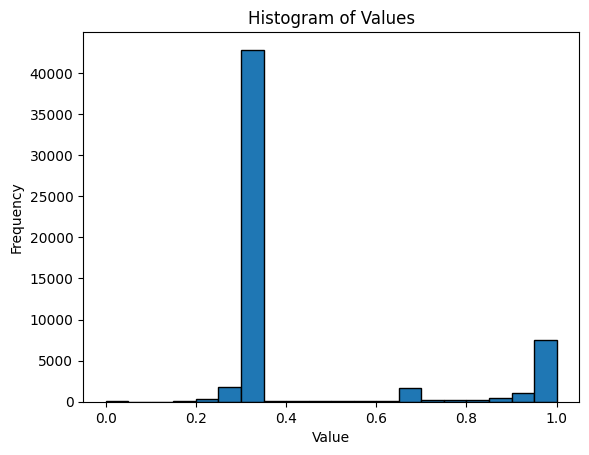

In [8]:
import matplotlib.pyplot as plt

plt.hist(result["non_null_percentage"], bins=20, edgecolor='black')
plt.title("Histogram of Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


In [9]:
result_greater_than_98 = result.filter(pl.col("non_null_percentage") >= 0.98)

In [10]:
result_greater_than_98

ID,non_null_percentage
str,f64
"""USW00053005""",1.0
"""USC00047702""",1.0
"""USC00165908""",1.0
"""USC00311441""",1.0
"""USC00208252""",1.0
…,…
"""USC00354060""",0.980034
"""USC00459074""",0.98003
"""USC00419088""",0.980015


In [11]:
values_list = result_greater_than_98["ID"].to_list()


In [12]:
filtered_df = df.filter(pl.col("ID").is_in(values_list))


In [13]:
filtered_df

ID,DATE,TMAX,TMIN,PRCP,Latitude,Longitude,Elevation
str,str,i64,i64,i64,f64,f64,f64
"""USC00201675""","""9/26/2012""",200,100,0,41.9622,-84.9925,299.9
"""USC00206510""","""8/2/2018""",267,156,28,45.3614,-84.9511,228.0
"""USC00352440""","""6/21/2012""",311,61,null,45.4539,-121.1303,405.4
"""USW00013866""","""12/1/2002""",6,-44,3,38.3794,-81.5911,278.0
"""USW00054780""","""10/17/2001""",172,100,0,41.0731,-71.9236,2.1
…,…,…,…,…,…,…,…
"""USW00023904""","""4/10/2018""",147,7,4,35.82,-91.7811,138.7
"""USW00003086""","""5/21/2012""",275,121,4,37.3814,-102.7194,1389.0
"""USW00063850""","""7/30/2012""",332,198,4,33.7836,-83.3897,225.9


In [14]:
df

ID,DATE,TMAX,TMIN,PRCP,Latitude,Longitude,Elevation
str,str,i64,i64,i64,f64,f64,f64
"""USS0012M13S""","""3/26/1997""",null,null,0,37.66,-112.74,2920.0
"""US1OKCV0021""","""4/18/2007""",null,null,241,35.1715,-97.4262,355.1
"""USC00355174""","""10/7/1999""",null,null,null,42.0078,-121.3186,1410.3
"""US1MDHW0012""","""10/14/2015""",null,null,0,39.3387,-76.9468,166.1
"""US1TXHRS014""","""10/4/2021""",null,null,0,32.7061,-94.1683,53.6
…,…,…,…,…,…,…,…
"""US1MNMW0008""","""11/14/2021""",null,null,5,43.6719,-93.0228,365.2
"""US1KSJA0001""","""8/27/2014""",null,null,5,39.3032,-95.8141,365.8
"""US1NEDG0029""","""6/15/2019""",null,null,5,41.214,-96.1908,366.1


In [15]:
filtered_df.write_csv("filtered_df.csv")


In [18]:
summary = filtered_df.describe()
summary

statistic,ID,DATE,TMAX,TMIN,PRCP,Latitude,Longitude,Elevation
str,str,str,f64,f64,f64,f64,f64,f64
"""count""","""42482360""","""42482360""",4.2208112e7,4.2189643e7,4.2201752e7,4.248236e7,4.248236e7,4.248236e7
"""null_count""","""0""","""0""",274248.0,292717.0,280608.0,0.0,0.0,0.0
"""mean""",null,null,171.385789,45.747035,24.60613,40.229175,-99.182832,744.143416
"""std""",null,null,119.119948,113.111176,78.110834,6.085418,16.749835,818.754502
"""min""","""US009052008""","""1/1/1992""",-999.0,-1150.0,0.0,19.2706,-170.2228,-999.9
"""25%""",null,null,83.0,-25.0,0.0,36.1561,-111.4336,165.5
"""50%""",null,null,183.0,47.0,0.0,40.4644,-97.7019,351.1
"""75%""",null,null,267.0,128.0,8.0,44.0206,-85.8889,1204.9
"""max""","""USW00096408""","""9/9/2021""",55372.0,30460.0,53365.0,71.2869,174.1,3541.8


In [19]:
import polars as pl
import polars.selectors as cs


def quantDDA(df_input: pl.DataFrame) -> pl.DataFrame:
    # 1. Grab numeric columns and define the total observation count
    numeric_cols = df_input.select(cs.numeric()).columns
    total_obs = len(df_input)  # Defined as lowercase [cite: 24]
    
    # 2. Base metrics for ALL columns
    stats = [
        pl.lit(total_obs).alias("Total_Obs"),
        cs.all().count().name.prefix("Entries_"),
        cs.all().n_unique().name.prefix("Unique_"),
        cs.all().null_count().name.prefix("Null_"),
    ]

    # 3. Numeric-specific metrics
    for col in numeric_cols:
        series = df_input.get_column(col)
        # Calculate quantiles once to avoid multiple passes [cite: 35, 41]
        q1 = series.quantile(0.25)
        q2 = series.quantile(0.5)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        p01, p99 = series.quantile(0.01), series.quantile(0.99) 

        stats.extend([
            ((pl.col(col) < (q1 - 1.5 * iqr)) | (pl.col(col) > (q3 + 1.5 * iqr))).sum().alias(f"Outliers_{col}"),
            ((pl.col(col) < p01) | (pl.col(col) > p99)).sum().alias(f"Extreme_{col}"),
            pl.col(col).mode().first().alias(f"Mode_{col}"),
            pl.col(col).mean().round(2).alias(f"Mean_{col}"),
            pl.col(col).std().round(2).alias(f"StdDev_{col}"),
            pl.col(col).max().alias(f"Max_{col}"),
            pl.col(col).min().alias(f"Min_{col}"),
            pl.lit(q1).alias(f"Q1_{col}"),
            pl.lit(q2).alias(f"Q2_{col}"),
            pl.lit(q3).alias(f"Q3_{col}"),
            pl.col(col).skew().round(4).alias(f"Skew_{col}"),
            pl.col(col).kurtosis().round(4).alias(f"Kurt_{col}"),
        ])

    # 4. Add the Percent Presence metric (Fixed Variable Name) [cite: 147]
    # This uses (count / total_obs) * 100 to show the percentage of non-null values
    stats.append(
        ((cs.all().count() / total_obs) * 100).round(2).name.prefix("NonMissingPct_")
    )

    # 5. Execute aggregations and Pivot [cite: 64, 74]
    res_wide = df_input.select(stats)
    res_long = res_wide.melt().with_columns(
        pl.col("variable").str.splitn("_", 2).struct.field("field_0").alias("Stat"),
        pl.col("variable").str.splitn("_", 2).struct.field("field_1").alias("Feature")
    )

    final_df = res_long.pivot(index="Feature", on="Stat", values="value")
    
    # 6. Final Formatting [cite: 76, 79]
    final_df = final_df.fill_null("-")
    
    # Ensure NonMissingPct is the last column
    if "NonMissingPct" in final_df.columns:
        cols = [c for c in final_df.columns if c != "NonMissingPct"] + ["NonMissingPct"]
        final_df = final_df.select(cols)
    
    return final_df

In [21]:
quantDDA(filtered_df)

/var/folders/p0/bwyhv2hx34gg8rw1ds61z4k80000gn/T/ipykernel_73713/53719262.py:51: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  res_long = res_wide.melt().with_columns(


Feature,Total,Entries,Unique,Null,Outliers,Extreme,Mode,Mean,StdDev,Max,Min,Q1,Q2,Q3,Skew,Kurt,NonMissingPct
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Obs""",4.248236e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ID""",null,4.248236e7,5425.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,100.0
"""DATE""",null,4.248236e7,10593.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,100.0
"""TMAX""",null,4.2208112e7,1452.0,274248.0,78052.0,802666.0,267.0,171.39,119.12,55372.0,-999.0,83.0,183.0,267.0,3.8854,1480.3747,99.35
"""TMIN""",null,4.2189643e7,1084.0,292717.0,269824.0,732038.0,0.0,45.75,113.11,30460.0,-1150.0,-25.0,47.0,128.0,24.5348,6467.7451,99.31
"""PRCP""",null,4.2201752e7,2041.0,280608.0,8.369765e6,420070.0,0.0,24.61,78.11,53365.0,0.0,0.0,0.0,8.0,15.3364,5512.9381,99.34
"""Latitude""",null,4.248236e7,5050.0,0.0,1.038815e6,839605.0,45.19,40.23,6.09,71.2869,19.2706,36.1561,40.4644,44.0206,0.6313,2.6878,100.0
"""Longitude""",null,4.248236e7,5228.0,0.0,450884.0,844447.0,-106.61,-99.18,16.75,174.1,-170.2228,-111.4336,-97.7019,-85.8889,-0.4567,1.9359,100.0
"""Elevation""",null,4.248236e7,2726.0,0.0,1.320884e6,826612.0,3.0,744.14,818.75,3541.8,-999.9,165.5,351.1,1204.9,1.3086,0.7336,100.0
